# Transformery EnglandWeather

## Biblioteki

In [20]:
from transformers import PatchTSTConfig, PatchTSTForPrediction, EarlyStoppingCallback, TrainingArguments, Trainer, AutoformerConfig, AutoformerModel
import gdown
import pandas as pd
from sklearn.preprocessing import StandardScaler
from torch.utils.data import Dataset
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error

## Przygotowanie danych:

In [21]:
file_id = 'EnglandWeather.csv'
url_pogoda = 'https://drive.google.com/file/d/1eBrZ3r3I_7Jn_nMSuAd1tPZrIHMfNEXB/view?usp=sharing'

gdown.download(url_pogoda, file_id, quiet=False, fuzzy=True)
data_weather = pd.read_csv("EnglandWeather.csv")

data_weather['Formatted Date'] = pd.to_datetime(data_weather['Formatted Date'], format='mixed', utc = True).dt.tz_localize(None)

# posortowanie i uporządkowanie
data_weather = data_weather.sort_values('Formatted Date')
data_weather = data_weather.set_index('Formatted Date')

# usuwanie duplikatów
data_weather = data_weather[~data_weather.index.duplicated(keep='first')]

# pozostawienie 4 zmiennych
ts_weather = data_weather[['Temperature (C)', 'Humidity', 'Wind Speed (km/h)', 'Pressure (millibars)']].resample('h').mean()
# podstawienie brakujących wartości godzinowych
ts_weather = ts_weather.interpolate(method='linear')
ts_weather = ts_weather[['Temperature (C)']].copy()
ts_weather.columns = ['Temp']

train_weather= ts_weather[:'2014-01-31'].copy()
test_weather = ts_weather['2014-02-01':].copy()

#print(len(train_weather)) #70873
#print(len(test_weather)) #25559
train_weather.head()
test_weather.head()

Downloading...
From: https://drive.google.com/uc?id=1eBrZ3r3I_7Jn_nMSuAd1tPZrIHMfNEXB
To: /Users/olgaforiasz/Documents/EnglandWeather.csv
100%|██████████| 7.58M/7.58M [00:00<00:00, 55.0MB/s]


,Temp
Formatted Date,
2014-02-01 00:00:00,-5.561111
2014-02-01 01:00:00,-5.600000
2014-02-01 02:00:00,-5.600000
2014-02-01 03:00:00,-5.638889
2014-02-01 04:00:00,-6.105556


## Okna czasowe

In [35]:
class Weather_Dataset(Dataset):
    def __init__(self, data_a, con_length, pred_length, is_autoformer=False):
        self.data = data_a
        self.con_length = con_length
        self.pred_length = pred_length
        self.is_autoformer=is_autoformer

    def __len__(self):
        return(len(self.data)-self.con_length-self.pred_length+1) # wyznacza nam ile okien sie zmiesci

    def __getitem__(self, index):
        past_val = self.data[index : index + self.con_length]
        future_val = self.data[index + self.con_length : index + self.con_length + self.pred_length]

        if self.is_autoformer==False:
            output ={
                "past_values": torch.tensor(past_val, dtype=torch.float32).unsqueeze(-1),
                "future_values": torch.tensor(future_val, dtype=torch.float32).unsqueeze(-1),
                "past_observed_mask": torch.ones(self.con_length, dtype=torch.float32).unsqueeze(-1)}
        
        if self.is_autoformer==True:
            output ={
                "past_values": torch.tensor(past_val, dtype=torch.float32),
                "future_values": torch.tensor(future_val, dtype=torch.float32),
                "past_observed_mask": torch.ones(self.con_length, dtype=torch.float32),
                "past_time_features": torch.zeros((self.con_length,1),dtype=torch.float32),
                "future_time_features": torch.zeros((self.pred_length,1),dtype=torch.float32),
                "static_categorical_features": torch.zeros(1,dtype=torch.long),
                "static_real_features": torch.zeros(1,dtype=torch.float32)
                                                  
            }
        return output


## Obiekty

In [36]:
con_length = 72
pred_length = 24

train_array = train_weather['Temp'].values
test_array=test_weather['Temp'].values

train_dataset = Weather_Dataset(
    train_array,
    con_length,
    pred_length,
    is_autoformer=False
)

test_dataset = Weather_Dataset(
    test_array,
    con_length,
    pred_length,
    is_autoformer=False
)


## Przygotowanie modelu PatchTST:

In [37]:
configuration = PatchTSTConfig(context_length=con_length, prediction_length=pred_length, num_input_channels=1, patch_length=12,
                               stride=12 , d_model=32, encoder_layers=2, dropout=0.0, use_reversible_instance_norm=True)
model = PatchTSTForPrediction(configuration)
# print(model.num_parameters())

## Trenowanie modelu PatchTST:

In [38]:
batch_size = 64
num_workers = 8

# z dokumentacji na hugging face

training_args = TrainingArguments(
    output_dir="./patchTST",
    learning_rate=1e-3,
    num_train_epochs=10,
    eval_strategy="epoch",
    per_device_train_batch_size= batch_size,
    per_device_eval_batch_size= batch_size,
    #dataloader_num_workers=num_workers,
    save_strategy="no",
    logging_strategy="epoch",
    max_grad_norm=1.0,
    label_names=["future_values"],
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset
)

trainer.train()


Epoch,Training Loss,Validation Loss
1,9.156467,7.418471
2,6.947883,6.641660
3,6.323327,6.488341
4,6.047096,6.362476
5,5.874415,6.249605
6,5.729593,6.160640
7,5.615793,6.127524
8,5.517023,6.046002
9,5.435556,6.068285
10,5.368429,6.011730


TrainOutput(global_step=11060, training_loss=6.201558350050859, metrics={'train_runtime': 275.7203, 'train_samples_per_second': 2567.022, 'train_steps_per_second': 40.113, 'total_flos': 35514747025920.0, 'train_loss': 6.201558350050859, 'epoch': 10.0})

## Prognozowanie za pomocą modelu PatchTST:

Błąd (MAE):1.04 °C
Błąd RMSE: 1.31 °C


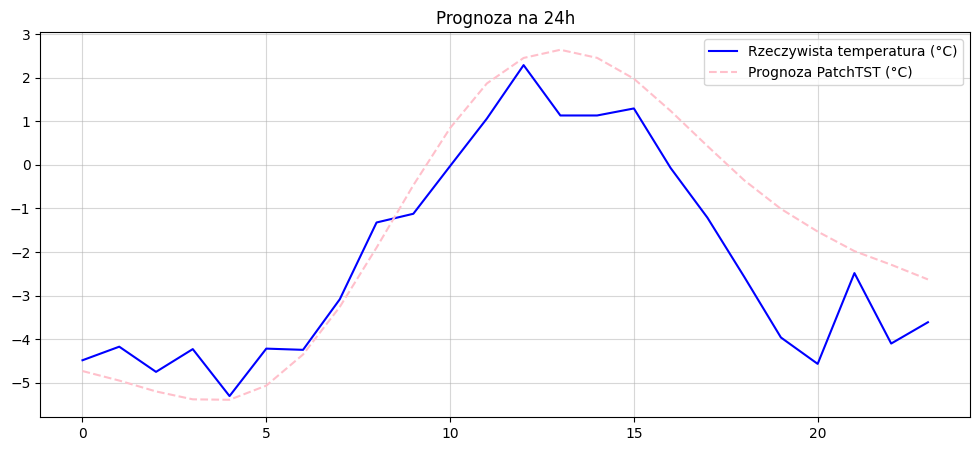

In [39]:
test_results = trainer.predict(test_dataset)
logits = test_results.predictions[0] 
pred = logits[0].flatten()
act = test_dataset[0]['future_values'].numpy().flatten()

# Bledy
mae = mean_absolute_error(act, pred)
rmse = np.sqrt(mean_squared_error(act, pred))
print(f"Błąd (MAE):{mae:.2f} °C")
print(f"Błąd RMSE: {rmse:.2f} °C")

plt.figure(figsize=(12, 5))
plt.plot(act, label="Rzeczywista temperatura (°C)", color='blue')
plt.plot(pred, label="Prognoza PatchTST (°C)", color='pink', linestyle='--')
plt.legend()
plt.grid(True, alpha=0.5)
plt.title("Prognoza na 24h")
plt.show()